*This code calculates how much more efficiently a model with the same loss as the brain could be trained, were the brain trained 'compute efficiently'. (See diagram below.) It was written by Tamay Besiroglu and lightly edited by Tom Davidson.*

In [4]:
import numpy as np
import math

def compute_loss(N, D):
    """
    Compute the loss given number of parameters N and training points D.
    """
    return 1.8172 + 482.01 / (N ** 0.3478) + 2085.43 / (D ** 0.3658)

# -----------------------------------------------------------------------
# Brain (given)
# -----------------------------------------------------------------------
N_A = 1e14            # Brain parameters
C_A = 1e24   # Brain 'training compute'
D_A = 1e24/(1e14*6)        # Brain number of 'data points'
L_A = compute_loss(N_A, D_A)

print("Brain:")
print("  N_A =", format(N_A, ".1e") )
print("  D_A =", format(D_A, ".1e") )
print("  Loss L_A =", format(L_A, ".1e") )
print("  Compute C_A =", format(C_A, ".1e") )
print()

# -----------------------------------------------------------------------
# Model B (Compute-Optimal)
# -----------------------------------------------------------------------
# We want to match L_A, i.e.:
#    1.8172 + 482.01/(N^a) + 2085.43/(D^b) = L_A
# Define:
a = 0.3478
b = 0.3658
E = L_A - 1.8172   # So that 482.01/(N^a) + 2085.43/(D^b) = E

def loss_constraint(N):
    """
    Given N, solve for D such that the constraint is satisfied:
      482.01/(N^a) + 2085.43/(D^b) = E

    Returns (D, is_feasible).
    If no feasible D exists (the required D would be complex or negative),
    return (None, False).
    """
    termN = 482.01 / (N ** a)
    # If termN >= E, then 2085.43/(D^b) = E - termN would be <= 0 => not feasible
    if termN >= E:
        return (None, False)
    # Solve for D^b = 2085.43 / (E - termN)
    remainder = E - termN
    if remainder <= 0:
        return (None, False)
    D = (2085.43 / remainder) ** (1.0 / b)
    return (D, True)

def compute_cost(N):
    """
    Returns the compute cost = 6*N*D subject to L(N,D) = L_A
    or float('inf') if infeasible.
    """
    D, feasible = loss_constraint(N)
    if not feasible:
        return float('inf')
    return 6.0 * N * D

# We'll do a simple 1D search in log-space over N.
# You can refine the range or the number of samples as needed.
N_values = np.logspace(5, 18, 300)  # Searching from 1e5 up to 1e18, 300 points

best_cost = float('inf')
best_N = None
best_D = None

for N in N_values:
    cost = compute_cost(N)
    if cost < best_cost:
        best_cost = cost
        best_N = N

# Once we have the best_N, we can get the corresponding D.
best_D, _ = loss_constraint(best_N)

# Compute final metrics
L_B = compute_loss(best_N, best_D)
C_B = 6 * best_N * best_D

print("Model B (Compute-Optimal via Numeric Search):")
print("  N_B =", format(best_N, ".1e") )
print("  D_B =", format(best_D, ".1e"))
print("  Loss L_B =", format(L_B, ".1e"))
print("  Compute C_B =", format(C_B, ".1e") )
print()

# Check that the losses match
if math.isclose(L_A, L_B, rel_tol=1e-6):
    print("The losses for Brain and Model B match (within tolerance).")
else:
    print("The losses differ!")

# Compare compute budgets
ratio = - np.log10(C_B) + np.log10(C_A)
print()
print("Model B uses about {:.2e} OOMs less than Brain.".format(ratio))

Brain:
  N_A = 1.0e+14
  D_A = 1.7e+09
  Loss L_A = 2.7e+00
  Compute C_A = 1.0e+24

Model B (Compute-Optimal via Numeric Search):
  N_B = 5.0e+08
  D_B = 1.2e+10
  Loss L_B = 2.7e+00
  Compute C_B = 3.5e+19

The losses for Brain and Model B match (within tolerance).

Model B uses about 4.46e+00 OOMs less than Brain.


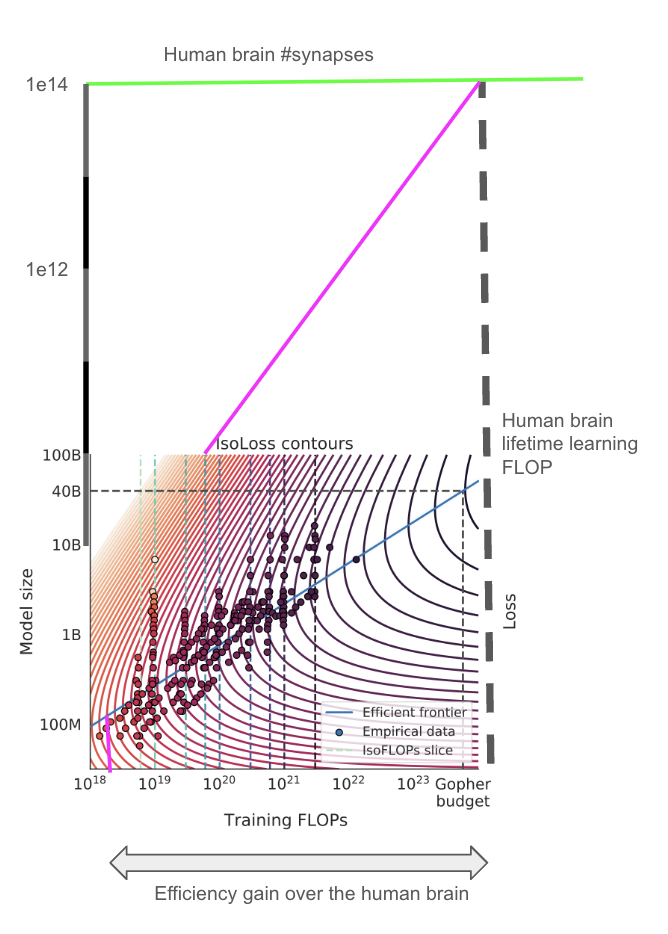